# Notebook 4: LoRA Fine-Tuning on a Small Model
## Customer Support Chatbot with Qwen2.5-1.5B-Instruct

This notebook teaches **LoRA (without quantization)** by fine-tuning a small model that fits
comfortably in GPU memory without any quantization tricks.

### Why This Notebook?

In Notebooks 1 and 3 we used **QLoRA** — where the base model is quantized to 4-bit and LoRA adapters
are trained on top. QLoRA is essential for large models (7B+) that wouldn't otherwise fit on consumer GPUs.

But here's the key question: **what if the model is small enough to fit in memory without quantization?**

With a **1.5B parameter model in BFloat16**, the base weights occupy only ~3 GB of VRAM. That leaves
plenty of room on a 15 GB GPU for LoRA adapters, optimizer states, gradients, and activations — no
quantization needed.

This gives us a cleaner setup to study **pure LoRA** and a chance to work with a **real-world dataset**
(customer support) instead of the toy Yoda dataset.

### What You'll Learn

1. **LoRA without quantization** — loading a model in BFloat16 and attaching LoRA adapters directly
2. **Real-world dataset preparation** — converting the Bitext customer support dataset to conversational format
3. **Train/validation splitting** — proper evaluation during training (not just eyeballing outputs)
4. **System prompts** — shaping model behavior with a system message in the chat template
5. **Before vs. After comparison** — querying the base model and fine-tuned model on the same prompts
6. **Per-category evaluation** — checking if the model learned different intent types equally well

### Key Difference from Notebooks 1 & 3

| | Notebooks 1 & 3 (QLoRA) | This Notebook (LoRA) |
|---|---|---|
| **Base model** | Phi-3-mini-4k (3.8B) | Qwen2.5-1.5B-Instruct |
| **Base model precision** | 4-bit (NF4 quantized) | BFloat16 (no quantization) |
| **Why quantize?** | 3.8B in BF16 = ~7.6 GB, tight fit | 1.5B in BF16 = ~3 GB, fits easily |
| **Adapter type** | QLoRA (LoRA on quantized base) | Pure LoRA (LoRA on full-precision base) |
| **Dataset** | Yoda sentences (720 examples, toy) | Bitext customer support (27K examples, real-world) |
| **Evaluation** | Visual inspection only | Train/val split + loss monitoring |

The **LoRA math is identical** in both cases — the only difference is whether the frozen base model
underneath is quantized or not. This is the key insight from the slides:

> *"QLoRA = quantized base + LoRA adapters. LoRA = full-precision base + LoRA adapters."*

---
## Setup

In [1]:
# Install pinned versions for reproducibility
!pip install transformers==4.56.1 peft==0.17.0 accelerate==1.10.0 trl==0.23.1 datasets==4.0.0 huggingface-hub==0.34.4 safetensors==0.6.2 pandas==2.2.2 matplotlib==3.10.0 numpy==2.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.9/503.9 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.7/374.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.6/564.6 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.8/485.8 kB 45.8 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: transformers
    Found existing installation: transf

### Imports

In [2]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from contextlib import nullcontext
from collections import Counter

from datasets import load_dataset, DatasetDict
from peft import get_peft_model, LoraConfig, TaskType
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

### GPU Check

Let's verify we have a GPU and check how much VRAM is available. A T4 (15 GB), L4 (24 GB),
or any similar consumer GPU will work perfectly for this notebook.

In [5]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"Total VRAM: {total_mem:.1f} GB")
else:
    print("⚠️ No GPU found! This notebook requires a CUDA GPU.")
    print("In Colab: Runtime → Change runtime type → T4 GPU")

GPU: Tesla T4
Total VRAM: 15.6 GB


---
## Part 1: Loading the Base Model (No Quantization!)

Since Qwen2.5-1.5B-Instruct has only 1.5 billion parameters, loading it in BFloat16 takes
roughly **3 GB of VRAM**. Compare that to Phi-3-mini at 3.8B parameters which needs ~7.6 GB
in BFloat16 — that's why we quantized it in Notebooks 1 & 3.

Here, we skip `BitsAndBytesConfig` entirely. No `load_in_4bit`, no `bnb_4bit_quant_type`.
Just a straightforward model load in half-precision.

In [6]:
repo_id = "Qwen/Qwen2.5-1.5B-Instruct"

# Detect if GPU supports BFloat16 natively (Ampere+: A100, RTX 3090, T4, L4, etc.)
supported = torch.cuda.is_bf16_supported(including_emulation=False)
dtype = torch.bfloat16 if supported else torch.float16
print(f"Using dtype: {dtype}")

model = AutoModelForCausalLM.from_pretrained(
    repo_id,
    torch_dtype=dtype,
    device_map="auto"          # automatically places model on GPU
    # NOTE: No quantization_config! That's the whole point.
)

Using dtype: torch.float16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

### Memory Footprint

Let's see how much space the model takes. With 1.5B parameters in BFloat16 (2 bytes each),
we expect roughly 1.5B × 2 = ~3 GB.

In [7]:
print(f"Model memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

Model memory footprint: 3.09 GB


### Inspecting the Architecture

Let's look at the model's layer structure. Notice that the linear layers are **regular `Linear`
layers** — NOT `Linear4bit` like we saw in the QLoRA notebooks. This confirms the model is loaded
at full BFloat16 precision.

In [8]:
# Show just the first decoder layer to see the structure
print(model.model.layers[0])

Qwen2DecoderLayer(
  (self_attn): Qwen2Attention(
    (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
    (k_proj): Linear(in_features=1536, out_features=256, bias=True)
    (v_proj): Linear(in_features=1536, out_features=256, bias=True)
    (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
    (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
    (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
  (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
)


Compare this to Notebook 1 where you saw `lora.Linear4bit` — here you'll see standard
`torch.nn.Linear` layers. When we add LoRA, these will become `lora.Linear` (not `lora.Linear4bit`).

---
## Part 2: Exploring the Dataset

The [Bitext Customer Support dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset)
contains ~27,000 customer service interactions covering 27 different intents across 11 categories.

This is a **real-world dataset** — the kind you'd actually encounter when building a customer
support chatbot for a company. Each example has:

- **`instruction`**: the customer's message (e.g., *"I need to cancel my order"*)
- **`response`**: the ideal agent reply
- **`intent`**: what the customer wants (e.g., `cancel_order`)
- **`category`**: high-level grouping (e.g., `ORDER`)

In [9]:
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
    split="train"
)
print(f"Total examples: {len(dataset)}")
print(f"Columns: {dataset.column_names}")

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Total examples: 26872
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


In [10]:
# Let's look at a few examples
dataset[0]

{'flags': 'B',
 'instruction': 'question about cancelling order {{Order Number}}',
 'category': 'ORDER',
 'intent': 'cancel_order',
 'response': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}

### Dataset Statistics

Understanding your dataset is a critical step that's often skipped. Let's look at the
distribution of intents and categories.

In [11]:
# Count examples per category
category_counts = Counter(dataset['category'])
print("Examples per category:")
print("-" * 40)
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:25s} {count:5d}")
print(f"{'':25s} -----")
print(f"  {'TOTAL':25s} {sum(category_counts.values()):5d}")

Examples per category:
----------------------------------------
  ACCOUNT                    5986
  ORDER                      3988
  REFUND                     2992
  INVOICE                    1999
  CONTACT                    1999
  PAYMENT                    1998
  FEEDBACK                   1997
  DELIVERY                   1994
  SHIPPING                   1970
  SUBSCRIPTION                999
  CANCEL                      950
                          -----
  TOTAL                     26872


In [12]:
# Count examples per intent
intent_counts = Counter(dataset['intent'])
print(f"\nNumber of unique intents: {len(intent_counts)}")
print(f"\nExamples per intent (top 10):")
for intent, count in intent_counts.most_common(10):
    print(f"  {intent:35s} {count:5d}")


Number of unique intents: 27

Examples per intent (top 10):
  check_invoice                        1000
  complaint                            1000
  contact_customer_service             1000
  edit_account                         1000
  switch_account                       1000
  check_payment_methods                 999
  contact_human_agent                   999
  delivery_period                       999
  get_invoice                           999
  newsletter_subscription               999


### Subsampling the Dataset

The full 27K dataset would work fine, but training on all of it would take a while. For this
teaching notebook, we'll use a **stratified sample of 2,000 examples** — enough to see clear
learning, fast enough to train in ~15 minutes.

In practice, the slides mention that **1,000 high-quality examples often outperform 100,000 noisy ones**.
We'll keep 2,000 to have a healthy train/validation split.

In [13]:
import random
random.seed(42)

# Stratified sample: take proportional examples from each intent
# This ensures the model sees all 27 intents during training
sampled_indices = []
examples_per_intent = 74  # ~2000 / 27 intents ≈ 74 each

intent_to_indices = {}
for i, intent in enumerate(dataset['intent']):
    intent_to_indices.setdefault(intent, []).append(i)

for intent, indices in intent_to_indices.items():
    random.shuffle(indices)
    sampled_indices.extend(indices[:examples_per_intent])

random.shuffle(sampled_indices)
sampled_dataset = dataset.select(sampled_indices)
print(f"Sampled dataset size: {len(sampled_dataset)}")
print(f"Intents covered: {len(set(sampled_dataset['intent']))}")

Sampled dataset size: 1998
Intents covered: 27


---
## Part 3: Preparing the Dataset for Training

Just like in Notebooks 1 & 3, the `SFTTrainer` expects data in **conversational format**:
messages with `role` and `content` fields.

But this time, we'll also add a **system prompt** — a message that tells the model *what role it
should play*. This is standard practice in production chatbots and something the Qwen2.5 model
was specifically trained to handle well.

In [14]:
SYSTEM_PROMPT = (
    "You are a helpful customer support assistant. "
    "Respond to customer inquiries professionally, clearly, and concisely. "
    "Always be empathetic and solution-oriented."
)

def format_to_conversational(examples):
    """Convert instruction/response pairs to the conversational format
    expected by SFTTrainer, including a system prompt."""
    if isinstance(examples["instruction"], list):
        all_messages = []
        for i in range(len(examples["instruction"])):
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": examples["instruction"][i]},
                {"role": "assistant", "content": examples["response"][i]},
            ]
            all_messages.append(messages)
        return {"messages": all_messages}
    else:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": examples["instruction"]},
            {"role": "assistant", "content": examples["response"]},
        ]
        return {"messages": [messages]}

# Apply formatting
formatted_dataset = sampled_dataset.map(
    format_to_conversational,
    remove_columns=sampled_dataset.column_names,  # drop all original columns
    batched=True
)

print("Sample formatted example:")
formatted_dataset[0]['messages']

Map:   0%|          | 0/1998 [00:00<?, ? examples/s]

Sample formatted example:


[{'content': 'You are a helpful customer support assistant. Respond to customer inquiries professionally, clearly, and concisely. Always be empathetic and solution-oriented.',
  'role': 'system'},
 {'content': 'I want to check what hours customer support available is',
  'role': 'user'},
 {'content': "We're all ears! I'm tuned into the idea that you would like to know the operating hours when our customer support team is available. Our dedicated team is here to assist you during {{Customer Support Hours}}. If you have any other questions or concerns, feel free to let me know. I'm here to help!",
  'role': 'assistant'}]

### Train/Validation Split

Unlike the Yoda notebook which used the entire dataset for training (because it was tiny),
here we hold out 10% for validation. This lets us monitor whether the model is **overfitting**
during training — a critical practice the slides emphasize.

> *"Evaluate on a held-out validation set to detect overfitting."* — Module 7 slides

In [15]:
split = formatted_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split['train']
val_dataset = split['test']

print(f"Training examples:   {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")

Training examples:   1798
Validation examples: 200


### Tokenizer Setup

Let's load the tokenizer and inspect the chat template. Qwen2.5 uses a ChatML-style template
with `<|im_start|>` and `<|im_end|>` tokens.

In [16]:
tokenizer = AutoTokenizer.from_pretrained(repo_id)

# Qwen2.5 already has a proper pad token set, let's verify
print(f"Pad token:     '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
print(f"EOS token:     '{tokenizer.eos_token}' (ID: {tokenizer.eos_token_id})")
print(f"Vocab size:    {tokenizer.vocab_size}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pad token:     '<|endoftext|>' (ID: 151643)
EOS token:     '<|im_end|>' (ID: 151645)
Vocab size:    151643


In [17]:
# Let's see what the chat template produces for our first example
sample_messages = train_dataset[0]['messages']
formatted_text = tokenizer.apply_chat_template(sample_messages, tokenize=False)
print("Formatted chat template output:")
print(formatted_text)

Formatted chat template output:
<|im_start|>system
You are a helpful customer support assistant. Respond to customer inquiries professionally, clearly, and concisely. Always be empathetic and solution-oriented.<|im_end|>
<|im_start|>user
how can i cancel my subscription to ur corporate newsletter<|im_end|>
<|im_start|>assistant
I apologize for any inconvenience caused by the need to cancel your subscription to our corporate newsletter. I completely understand that circumstances may change, and you may no longer wish to receive our updates. To assist you with canceling your subscription, please provide me with the email address or any other relevant information associated with your subscription. With this information, I can promptly process the cancellation request and ensure that you stop receiving our newsletters. Rest assured, we value your decision and will respect your privacy throughout this process. If there is anything else I can assist you with, please feel free to let me know.

Notice how the template wraps each role in `<|im_start|>role` and `<|im_end|>` tags.
This is the ChatML format that Qwen2.5 was instruction-tuned with. The SFTTrainer will
apply this template automatically during training.

### Sequence Length Analysis

Before training, let's check how long our tokenized examples are. This helps us choose the
`max_length` parameter — too short and we truncate valuable data, too long and we waste
memory on padding.

Sequence length statistics:
  Min:    67
  Max:    476
  Mean:   178
  Median: 157
  95th percentile: 306


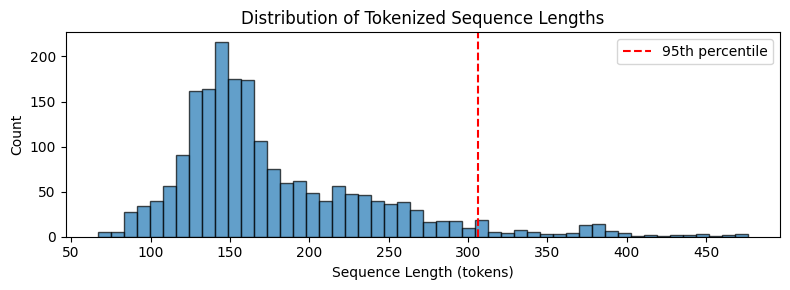

In [18]:
# Tokenize all examples to check lengths
lengths = []
for example in formatted_dataset:
    text = tokenizer.apply_chat_template(example['messages'], tokenize=False)
    tokens = tokenizer(text)['input_ids']
    lengths.append(len(tokens))

print(f"Sequence length statistics:")
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Mean:   {sum(lengths)/len(lengths):.0f}")
print(f"  Median: {sorted(lengths)[len(lengths)//2]}")
print(f"  95th percentile: {sorted(lengths)[int(len(lengths)*0.95)]}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Sequence Length (tokens)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Tokenized Sequence Lengths')
ax.axvline(x=sorted(lengths)[int(len(lengths)*0.95)], color='red',
           linestyle='--', label='95th percentile')
ax.legend()
fig.tight_layout()
plt.show()

Based on this distribution, we'll set `max_length` to cover the 95th percentile. This
ensures the vast majority of examples are not truncated, while keeping memory usage reasonable.

---
## Part 4: Setting Up LoRA Adapters

This is where **pure LoRA** differs from **QLoRA**:

- In Notebook 1 (QLoRA), we called `prepare_model_for_kbit_training(model)` first to handle the
  quantized layers. Here, **we skip that step entirely** because there's nothing to prepare — the
  model is already in standard BFloat16.

- We go straight to `get_peft_model()` with a `LoraConfig`.

The LoRA configuration itself is the same as before:
- **`r=8`**: rank of the low-rank matrices (A and B)
- **`lora_alpha=16`**: scaling factor, typically 2× the rank
- **`target_modules`**: which linear layers get LoRA adapters

In [19]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    # Target the attention projection layers in Qwen2.5
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

# No prepare_model_for_kbit_training() needed!
# That function is only for quantized models.
model = get_peft_model(model, lora_config)

In [20]:
# Let's verify: the adapter layers should be regular lora.Linear, NOT lora.Linear4bit
print(model.model.model.layers[0].self_attn)

Qwen2Attention(
  (q_proj): lora.Linear(
    (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.05, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=1536, out_features=8, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=8, out_features=1536, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    (lora_magnitude_vector): ModuleDict()
  )
  (k_proj): lora.Linear(
    (base_layer): Linear(in_features=1536, out_features=256, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.05, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=1536, out_features=8, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=8, out_features=256, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    

In [21]:
trainable_params, total_params = model.get_nb_trainable_parameters()
print(f"Trainable parameters:    {trainable_params / 1e6:.2f}M")
print(f"Total parameters:        {total_params / 1e6:.2f}M")
print(f"Trainable fraction:      {100 * trainable_params / total_params:.2f}%")

print(f"\nModel memory footprint:  {model.get_memory_footprint() / 1e9:.2f} GB")

Trainable parameters:    2.18M
Total parameters:        1545.89M
Trainable fraction:      0.14%

Model memory footprint:  3.10 GB


With LoRA rank 8 on just the attention projections (q, k, v, o), we're training less than
1% of the total parameters. The base model stays completely frozen — only the small adapter
matrices receive gradient updates.

This is the same principle as in the QLoRA notebooks, but without the quantization layer underneath.

---
## Part 5: Querying the Base Model (Before Fine-Tuning)

Before we train, let's establish a **baseline** by asking the base model (with untrained LoRA
adapters, which output zeros initially) some customer support questions. This "before" snapshot
lets us clearly see the impact of fine-tuning.

In [22]:
def gen_prompt(tokenizer, user_message, system_prompt=SYSTEM_PROMPT):
    """Build a chat-formatted prompt for generation."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return prompt


def generate(model, tokenizer, prompt, max_new_tokens=128, skip_special_tokens=True):
    """Generate a response from the model given a formatted prompt."""
    tokenized_input = tokenizer(
        prompt, add_special_tokens=False, return_tensors="pt"
    ).to(model.device)

    model.eval()
    ctx = (
        torch.autocast(device_type=model.device.type, dtype=model.dtype)
        if model.dtype in [torch.float16, torch.bfloat16]
        else nullcontext()
    )
    with ctx:
        with torch.no_grad():
            generation_output = model.generate(
                **tokenized_input,
                eos_token_id=tokenizer.eos_token_id,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # greedy for reproducibility
            )

    # Decode only the NEW tokens (skip the prompt)
    new_tokens = generation_output[0][tokenized_input['input_ids'].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=skip_special_tokens)
    return response

In [24]:
# Test queries — a mix of different customer support intents
test_queries = [
    "I want to cancel my order #12345",
    "Where is my package? It was supposed to arrive yesterday.",
    "How do I change the shipping address on my order?",
    "I need a refund for a damaged item",
    "Can you help me set up a new account?",
]

print("=" * 70)
print("BASE MODEL RESPONSES (before fine-tuning)")
print("=" * 70)
for query in test_queries:
    prompt = gen_prompt(tokenizer, query)
    response = generate(model, tokenizer, prompt)
    print(f"\nCustomer: {query}")
    print(f"Agent:    {response}")
    print("-" * 70)

BASE MODEL RESPONSES (before fine-tuning)

Customer: I want to cancel my order #12345
Agent:    Hello! I'm sorry to hear that you're looking to cancel your order. To proceed with the cancellation of Order #12345, please follow these steps:

1. Log in to your account if you haven't already.
2. Navigate to the "My Orders" section or similar where you can view all your past orders.
3. Locate Order #12345 and click on it to open the details page.
4. On this page, look for an option to "Cancel Order." If available, select this option.

If you encounter any issues during this process, feel free to contact our customer service team
----------------------------------------------------------------------

Customer: Where is my package? It was supposed to arrive yesterday.
Agent:    I'm sorry to hear that your package hasn't arrived yet. Here are some steps you can take:

1. **Check Your Delivery Confirmation**: Look for any delivery confirmation emails or texts from the shipping company. They of

Notice how the base model's responses are **generic and verbose** — it tries to help, but
the responses lack the structured, professional tone of a trained customer support agent. After
fine-tuning, we'll see a dramatic difference.

---
## Part 6: Fine-Tuning with SFTTrainer

The training setup follows the same pattern as Notebook 1, with a few adjustments:

1. **`max_length=256`** — our sequences are longer than Yoda sentences
2. **`num_train_epochs=3`** — fewer epochs because we have more data (2K vs 720 examples)
3. **`eval_strategy="steps"`** — we'll evaluate on the validation set during training
4. **`bf16=True`** — since our model is already in BFloat16, training in mixed precision is natural

Since this is **pure LoRA** (no quantization), we don't need `paged_adamw_8bit` — standard
AdamW works fine because the optimizer states are small (only for the LoRA parameters).

In [25]:
sft_config = SFTConfig(
    ## GROUP 1: Memory usage
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    gradient_accumulation_steps=1,
    per_device_train_batch_size=8,
    auto_find_batch_size=True,        # halves batch size on OOM

    ## GROUP 2: Dataset-related
    max_length=256,
    packing=True,                     # packs short examples together, no padding waste
    packing_strategy='wrapped',

    ## GROUP 3: Training parameters
    num_train_epochs=3,
    learning_rate=2e-4,
    warmup_ratio=0.05,
    weight_decay=0.01,
    optim='adamw_torch',              # standard AdamW — no need for paged optimizer with pure LoRA
    lr_scheduler_type='cosine',

    ## GROUP 4: Evaluation
    eval_strategy="steps",
    eval_steps=50,
    per_device_eval_batch_size=8,

    ## GROUP 5: Logging & output
    logging_steps=10,
    logging_dir='./logs',
    output_dir='./qwen-customer-support-lora',
    report_to='none',
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,               # keep only 2 best checkpoints

    # BFloat16 mixed precision
    bf16=torch.cuda.is_bf16_supported(including_emulation=False),
)

### Creating the Trainer

In [26]:
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

Tokenizing train dataset:   0%|          | 0/1798 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/1798 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Packing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

### Training

Training ~2,000 examples for 3 epochs on a T4 should take roughly **10–15 minutes**. Watch
the training loss — it should decrease steadily. The validation loss (logged every 50 steps)
helps us detect overfitting: if val loss starts increasing while train loss keeps decreasing,
the model is memorizing rather than generalizing.

In [27]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,1.252400,1.199405,1.219538,102400.000000,0.706864
100,1.032900,0.998009,1.020293,204602.000000,0.738493
150,0.931200,0.930298,0.943184,306774.000000,0.749967
200,0.880000,0.890613,0.885086,407382.000000,0.758050
250,0.835900,0.866562,0.858432,509584.000000,0.762998
300,0.839800,0.848224,0.860880,611756.000000,0.765684
350,0.772400,0.838836,0.840389,712364.000000,0.768100
400,0.775400,0.833915,0.820358,814764.000000,0.769407
450,0.767700,0.832485,0.818974,916966.000000,0.769732


TrainOutput(global_step=471, training_loss=0.9394032823558572, metrics={'train_runtime': 879.4702, 'train_samples_per_second': 4.261, 'train_steps_per_second': 0.536, 'total_flos': 7554065266114560.0, 'train_loss': 0.9394032823558572, 'entropy': 0.7689827680587769, 'num_tokens': 957954.0, 'mean_token_accuracy': 0.7803921699523926, 'epoch': 3.0})

### Training Loss Curve

Let's plot the training and validation loss to visualize the learning process.

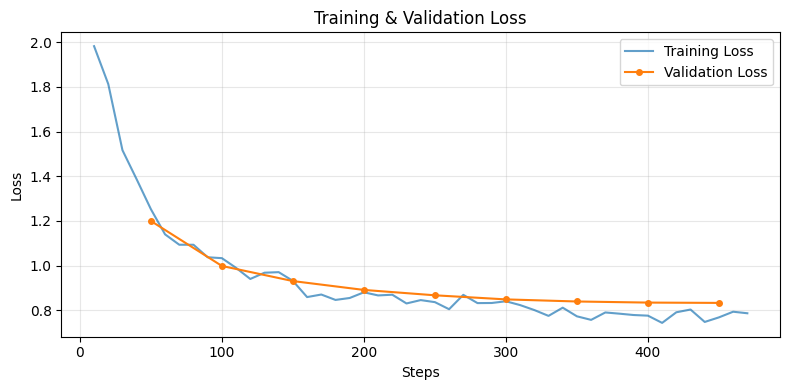

In [28]:
# Extract loss values from training history
train_losses = [(entry['step'], entry['loss'])
                for entry in trainer.state.log_history if 'loss' in entry]
eval_losses = [(entry['step'], entry['eval_loss'])
               for entry in trainer.state.log_history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label='Training Loss', alpha=0.7)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label='Validation Loss', marker='o', markersize=4)
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## Part 7: Querying the Fine-Tuned Model (After Fine-Tuning)

Now let's run the **exact same test queries** and compare the responses. The difference should
be immediately obvious — the fine-tuned model should respond like a professional customer
support agent.

In [29]:
print("=" * 70)
print("FINE-TUNED MODEL RESPONSES (after LoRA training)")
print("=" * 70)
for query in test_queries:
    prompt = gen_prompt(tokenizer, query)
    response = generate(model, tokenizer, prompt)
    print(f"\nCustomer: {query}")
    print(f"Agent:    {response[:300]}")
    print("-" * 70)

FINE-TUNED MODEL RESPONSES (after LoRA training)

Customer: I want to cancel my order #12345
Agent:    Thank you for reaching out! I'm here to assist you with cancelling your order number {{Order Number}}. To proceed with the cancellation, could you please provide me with some additional details? Specifically, do you have any specific reasons or concerns regarding this purchase? This information will
----------------------------------------------------------------------

Customer: Where is my package? It was supposed to arrive yesterday.
Agent:    I'm sorry for the inconvenience caused by your package not arriving as expected. To provide you with accurate information about where your package is located, could you please let me know which address it was delivered to? This will help us locate your package more efficiently and ensure that we can
----------------------------------------------------------------------

Customer: How do I change the shipping address on my order?
Agent:    I'm

### Testing on Unseen Intents

Let's also try some queries that weren't in our exact training data to test generalization:

In [30]:
unseen_queries = [
    "I was charged twice for my subscription",
    "How long does delivery take to Europe?",
    "I want to speak to a manager about my complaint",
    "Can you explain your return policy?",
    "I forgot my account password, how do I reset it?",
]

print("=" * 70)
print("GENERALIZATION TEST — Queries not seen during training")
print("=" * 70)
for query in unseen_queries:
    prompt = gen_prompt(tokenizer, query)
    response = generate(model, tokenizer, prompt)
    print(f"\nCustomer: {query}")
    print(f"Agent:    {response[:300]}")
    print("-" * 70)

GENERALIZATION TEST — Queries not seen during training

Customer: I was charged twice for my subscription
Agent:    We apologize for any inconvenience caused by the double charge on your subscription. To resolve this issue, could you please provide us with some additional information? Specifically, we would need details such as the date of purchase, the invoice number or account number associated with the subscri
----------------------------------------------------------------------

Customer: How long does delivery take to Europe?
Agent:    Thank you for your inquiry! I'm here to provide you with the information you need about the estimated delivery time for items shipped to Europe. To give you an accurate estimate, could you please let me know which specific product or order you're referring to? Once I have that information, I'll be a
----------------------------------------------------------------------

Customer: I want to speak to a manager about my complaint
Agent:    Thank you f

---
## Part 8: Saving the Adapter

Just like in Notebooks 1 & 3, the fine-tuned adapter is tiny — typically **10–50 MB**
compared to the 3 GB base model. This is the core advantage of LoRA: you store one base
model and swap lightweight adapters for different tasks.

In [31]:
# Save the LoRA adapter
adapter_path = "qwen-customer-support-lora-adapter"
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

# Show what was saved
print("Saved files:")
for f in sorted(os.listdir(adapter_path)):
    size = os.path.getsize(os.path.join(adapter_path, f))
    print(f"  {f:45s} {size/1e6:.2f} MB")

Saved files:
  README.md                                     0.01 MB
  adapter_config.json                           0.00 MB
  adapter_model.safetensors                     8.75 MB
  added_tokens.json                             0.00 MB
  chat_template.jinja                           0.00 MB
  merges.txt                                    1.67 MB
  special_tokens_map.json                       0.00 MB
  tokenizer.json                                11.42 MB
  tokenizer_config.json                         0.00 MB
  vocab.json                                    2.78 MB


### Loading the Adapter Back (Verification)

In production, you'd load the base model and then attach the saved adapter. Let's verify
this works:

In [32]:
from peft import PeftModel

# Load fresh base model
base_model = AutoModelForCausalLM.from_pretrained(
    repo_id,
    torch_dtype=dtype,
    device_map="auto"
)

# Attach the saved LoRA adapter
loaded_model = PeftModel.from_pretrained(base_model, adapter_path)

# Test it
prompt = gen_prompt(tokenizer, "I want to cancel my order #12345")
response = generate(loaded_model, tokenizer, prompt)
print(f"Response from loaded adapter:\n{response[:300]}")

Response from loaded adapter:
Thank you for reaching out! I'm here to assist you with cancelling your order number {{Order Number}}. To proceed with the cancellation, could you please provide me with some additional details? Specifically, do you have any specific reasons or concerns regarding this purchase? This information will


---
## Part 9: Key Takeaways

### LoRA vs QLoRA — When to Use Which

| Scenario | Use LoRA (this notebook) | Use QLoRA (Notebooks 1 & 3) |
|---|---|---|
| Model fits in VRAM at BF16 | ✅ Simpler, no quantization overhead | Unnecessary complexity |
| Model too large for VRAM at BF16 | Won't fit | ✅ Quantize to 4-bit to fit |
| Maximum training quality | ✅ No quantization error | Slight quality trade-off |
| Consumer GPU (12–16 GB) + 7B model | Won't fit (~14 GB just for weights) | ✅ ~3.5 GB for 4-bit weights |
| Consumer GPU (12–16 GB) + 1.5B model | ✅ ~3 GB in BF16, plenty of room | Works, but unnecessary |

### What We Demonstrated

1. **Pure LoRA** is simpler than QLoRA — no `BitsAndBytesConfig`, no `prepare_model_for_kbit_training`
2. **Small models + LoRA** is a sweet spot for consumer GPUs — fast iteration, easy debugging
3. **Real datasets require real preparation** — stratified sampling, train/val splits, sequence length analysis
4. **System prompts shape behavior** — the same LoRA fine-tuning pipeline works with different system prompts
5. **Adapter portability** — save a tiny adapter, reload it onto any instance of the same base model

### What's Next?

- **Notebook 5**: LoRA hyperparameter ablation — what happens when you change rank, alpha, and target modules?
- **Notebook 6**: Merge, export & deploy — convert your adapter to a standalone model and export to GGUF
- **Notebook 7**: Compare LoRA vs Prefix Tuning vs Prompt Tuning on the same task